<a href="https://colab.research.google.com/github/rmaturana-git/Challenge-Telecom-X/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [37]:
# Importar la librería principal
import pandas as pd

# Definir la URL
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'

# Cargar el DataFrame
df_churn = pd.read_json(url)

# Visualizar datos
df_churn.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## Conoce el conjunto de datos

### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

In [38]:
# Obtener información del DF
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [39]:
# Obtener Tipos de Datos de DF
df_churn.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [40]:
# Otra forma de verificar valores nulos por columna
df_churn.isna().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


## **Insights de la Extracción**

Se detecta que el DF cargado originalmente no coincide con el Diccionario de datos, esto se debe a que el JSON **tiene una estructura "Anidada"**, por lo tanto **es necesario hacer un "Aplanamiento"**.

#🔧 Transformación

## Aplanamiento del Json

In [41]:
# Importar herramienta de normalización
from pandas import json_normalize

# "Aplanar" los datos para que cada sub-campo sea una columna independiente
df_churn = json_normalize(df_churn.to_dict(orient='records'))

# Visualizar las primeras filas para confirmar que coinciden con el diccionario
df_churn.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [42]:
# Obtener información del DF
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [43]:
# Obtener Tipos de Datos de DF
df_churn.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [44]:
# Verificamos valores nulos por columna
df_churn.isna().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [45]:
# Convertir account.Charges.Total a tipo numérico
# errors='coerce' transformará cualquier texto no numérico (como espacios) en un valor nulo (NaN)
df_churn['account.Charges.Total'] = pd.to_numeric(df_churn['account.Charges.Total'], errors='coerce')

# Verificar los cambios en los tipos de datos
# Veremos que ahora account.Charges.Total es float64
df_churn.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [46]:
# Consultar nuevamente la cantidad de valores nulos en todo el DataFrame
# Esto nos permite ver si 'account.Charges.Total' ahora tiene valores vacíos
df_churn.isna().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [47]:
# Rellenar los valores nulos (NaN) con 0
# Usamos fillna(0) para que esos 11 casos dejen de ser "vacíos" y pasen a ser numéricos
df_churn['account.Charges.Total'] = df_churn['account.Charges.Total'].fillna(0)

# Verificar que el conteo de nulos sea ahora 0 para todas las columnas
# El Notebook mostrará la lista de columnas; busca 'account.Charges.Total' para confirmar
df_churn.isna().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [48]:
# Crear un diccionario de mapeo para renombrar las columnas
# La clave es el nombre actual y el valor es el nombre nuevo (limpio)
nuevos_nombres = {
    'customer.gender': 'gender',
    'customer.SeniorCitizen': 'SeniorCitizen',
    'customer.Partner': 'Partner',
    'customer.Dependents': 'Dependents',
    'customer.tenure': 'tenure',
    'phone.PhoneService': 'PhoneService',
    'phone.MultipleLines': 'MultipleLines',
    'internet.InternetService': 'InternetService',
    'internet.OnlineSecurity': 'OnlineSecurity',
    'internet.OnlineBackup': 'OnlineBackup',
    'internet.DeviceProtection': 'DeviceProtection',
    'internet.TechSupport': 'TechSupport',
    'internet.StreamingTV': 'StreamingTV',
    'internet.StreamingMovies': 'StreamingMovies',
    'account.Contract': 'Contract',
    'account.PaperlessBilling': 'PaperlessBilling',
    'account.PaymentMethod': 'PaymentMethod',
    'account.Charges.Monthly': 'Charges.Monthly',
    'account.Charges.Total': 'Charges.Total'
}

# Aplicar el cambio de nombre al DataFrame
# Usamos axis=1 para indicar que queremos renombrar las columnas (no las filas)
df_churn = df_churn.rename(columns=nuevos_nombres)

# 3. Visualizar las columnas actuales para confirmar el cambio
df_churn.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [49]:
df_churn.sample(10)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
1367,1976-AZZPJ,No,Male,0,Yes,No,7,No,No phone service,DSL,...,Yes,No,No,No,No,Month-to-month,No,Mailed check,34.20,256.60
60,0103-CSITQ,No,Female,0,Yes,No,57,Yes,Yes,Fiber optic,...,Yes,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),109.40,6252.70
4383,6000-UKLWI,No,Male,0,No,No,41,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.15,802.35
6225,8564-LDKFL,No,Male,0,Yes,No,40,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),106.00,4178.65
214,0324-BRPCJ,Yes,Female,1,Yes,No,68,Yes,Yes,Fiber optic,...,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.20,6851.65
6282,8640-SDGKB,Yes,Male,0,No,No,4,Yes,No,DSL,...,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,74.40,299.70
4218,5797-APWZC,Yes,Female,0,No,No,1,Yes,No,Fiber optic,...,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.60,90.60
5176,7064-JHXCE,No,Male,0,Yes,Yes,62,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),20.05,1263.90
6092,8327-WKMIE,No,Male,0,No,No,37,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.15,785.75
893,1261-FWTTE,No,Male,1,No,No,23,No,No phone service,DSL,...,No,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),34.65,768.45


## Corrección de inconsistencias detectadas

In [50]:
# 1. Eliminar filas donde 'Churn' esté vacío
# Esto es vital porque 'Churn' es nuestra variable objetivo
df_churn = df_churn[df_churn['Churn'] != ""]

# 2. Estandarizar 'PaymentMethod' (Quitar los paréntesis)
# Reemplazamos " (automatic)" por nada para simplificar
df_churn['PaymentMethod'] = df_churn['PaymentMethod'].str.replace(' (automatic)', '', regex=False)

# 3. Simplificar respuestas de servicios a Yes/No
# Reemplazamos las frases largas por un "No" estándar
columnas_servicios = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                     'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in columnas_servicios:
    df_churn[col] = df_churn[col].replace(['No internet service', 'No phone service'], 'No')

# 4. Visualizar una muestra aleatoria para verificar cambios
df_churn.sample(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
3530,4869-EPIUS,No,Male,0,Yes,No,56,Yes,No,Fiber optic,...,No,No,No,No,Yes,One year,Yes,Electronic check,80.90,4557.50
1128,1596-BBVTG,Yes,Male,0,No,No,35,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,No,Credit card,75.35,2636.05
5092,6961-VCPMC,Yes,Male,1,Yes,No,46,Yes,No,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,80.40,3605.20
6637,9124-LHCJQ,Yes,Female,0,No,No,1,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Mailed check,85.45,85.45
4017,5495-GPSRW,No,Male,0,No,No,20,Yes,No,No,...,No,No,No,No,No,Two year,Yes,Mailed check,19.70,419.40


## Comprobación de incoherencias en los datos

### Detección de Duplicados

In [51]:
# Contar cuántas filas están exactamente duplicadas
cantidad_duplicados = df_churn.duplicated().sum()

# Mostrar el resultado (si es 0, estamos bien)
cantidad_duplicados

np.int64(0)

### Verificación de Categorías (Valores Únicos)

In [52]:
# Revisar los valores únicos de las columnas categóricas más importantes
# Esto nos ayuda a ver si hay "categorías fantasma" o errores de dedo
{
    "Gender": df_churn['gender'].unique(),
    "Churn": df_churn['Churn'].unique(),
    "Contract": df_churn['Contract'].unique(),
    "PaymentMethod": df_churn['PaymentMethod'].unique()
}

{'Gender': array(['Female', 'Male'], dtype=object),
 'Churn': array(['No', 'Yes'], dtype=object),
 'Contract': array(['One year', 'Month-to-month', 'Two year'], dtype=object),
 'PaymentMethod': array(['Mailed check', 'Electronic check', 'Credit card', 'Bank transfer'],
       dtype=object)}

### Consistencia de Datos Numéricos vs Categorías

In [53]:
# Seleccionar las columnas que son de tipo 'object' (texto)
columnas_texto = df_churn.select_dtypes(include=['object']).columns

# Eliminar espacios en blanco invisibles al inicio o final de cada celda
for col in columnas_texto:
    df_churn[col] = df_churn[col].str.strip()

# Visualizar que no queden valores vacíos en Churn después del strip
df_churn['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


### Consistencia entre valores de la categorías

In [54]:
# Ver el conteo de cada categoría en columnas clave para detectar errores de escritura
# Si ves algo como "Male" y "male" por separado, sabremos que hay que unificar
{
    "Generos": df_churn['gender'].value_counts(),
    "Contratos": df_churn['Contract'].value_counts(),
    "Metodos_Pago": df_churn['PaymentMethod'].value_counts()
}

{'Generos': gender
 Male      3555
 Female    3488
 Name: count, dtype: int64,
 'Contratos': Contract
 Month-to-month    3875
 Two year          1695
 One year          1473
 Name: count, dtype: int64,
 'Metodos_Pago': PaymentMethod
 Electronic check    2365
 Mailed check        1612
 Bank transfer       1544
 Credit card         1522
 Name: count, dtype: int64}

### Resumen Estadístico (Detección de Outliers)

In [55]:
# Generar estadísticas descriptivas de las columnas numéricas
# Revisar que el 'min' no sea negativo y el 'max' tenga sentido
df_churn.describe()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### Agregar Columna de cuentas diarias

In [56]:
# Crear la columna 'Cuentas_Diarias'
# Dividimos el cargo mensual por 30 para obtener el costo por día
df_churn['Cuentas_Diarias'] = df_churn['Charges.Monthly'] / 30

# Visualizar las columnas relacionadas para verificar el cálculo
# Mostramos solo las columnas de cargos para comparar visualmente
df_churn[['Charges.Monthly', 'Cuentas_Diarias']].head()

,Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


### Estandarización y transformación de datos

In [57]:
# 1. Crear un diccionario para transformar valores textuales a binarios
# Yes/No -> 1/0
mapeo_binario = {'Yes': 1, 'No': 0}

# 2. Aplicar la transformación a las columnas que solo tienen Yes/No
# Usamos una lista de las columnas que queremos convertir
columnas_binarias = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in columnas_binarias:
    df_churn[col] = df_churn[col].map(mapeo_binario)

# 3. Traducir categorías de otras columnas para mejorar la comunicación
# Por ejemplo, en la columna 'gender' (Género)
mapeo_genero = {'Female': 'Femenino', 'Male': 'Masculino'}
df_churn['gender'] = df_churn['gender'].map(mapeo_genero)

# 4. Verificar los cambios
# Ahora verás números en lugar de Yes/No en las columnas seleccionadas
df_churn[['gender', 'Churn', 'Partner', 'Cuentas_Diarias']].head()

,gender,Churn,Partner,Cuentas_Diarias
0,Femenino,0,1,2.186667
1,Masculino,0,0,1.996667
2,Masculino,1,0,2.463333
3,Masculino,1,1,3.266667
4,Femenino,1,1,2.796667


## **Insights de la Transformación**

- Dentro de las categorías customer, phone, internet y account se encontraban más columnas ocultas que aparecieron con el aplanamiento
- El proceso de Aplanamiento agregó prefijos a las columnas ocultas, a las cuales se les aplicó un proceso para simplificar sus nombres y dejarlos como en el Diccionario de Datos
- Se encontró una inconsistencia importante en la columna account.Charges.Total. Según el diccionario, representa el total gastado por el cliente (un valor monetario), pero Pandas lo ha clasificado como object (texto), mientras que el cargo mensual (Monthly) sí es float64 (decimal).
- Al convertir account.Charges.Total a tipo float64 aparecieron nulos, probablente derivados de espacios en blanco de la estructura original.
- Se rellenan los casos "vacíos" con ceros para mantener consistencia de la información y no perder información
- Se detectaron incosistencias
  1. Inconsistencia en la columna Churn (Falta de datos): Se eliminan las filas (224 registros), ya que estos datos no sirven (No se sabe si el cliente se fue o quedó)
  2. Formato de nombres en PaymentMethod: Se eliminaron paréntisis y otros caracteres que estorben en las grágicas
  3. Valores "No internet service" y "No phone service": Se reemplazaron por "No" para mantener consistencia de dos posibles valores solamente (Yes/No)

#📊 Carga y análisis

### Análisis Descriptivo

In [58]:
import warnings
warnings.filterwarnings('ignore')

# Generar el resumen estadístico de las columnas numéricas
# Esto calculará la media (mean), desviación estándar (std), valor mínimo (min),
# los percentiles (25%, 50%, 75%) y el valor máximo (max).
# El 50% equivale a la Mediana.
df_churn.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,2.158723
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,1.003002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,1.183333
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [59]:
# Resumen estadístico para columnas de tipo objeto (texto)
# 'unique' nos dice cuántas categorías hay
# 'top' nos dice cuál es la categoría más frecuente (Moda)
# 'freq' nos dice cuántas veces aparece esa categoría más frecuente
df_churn.describe(include='object')

,customerID,gender,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,3,2,2,2,2,2,2,3,4
top,9995-HOTOH,Masculino,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check
freq,1,3555,4072,3096,5024,4614,4621,4999,4336,4311,3875,2365


#### **Insights del Anáslisi Descriptivo**

1. Análisis de Evasión (Churn)
  - Tasa de Evasión: La media de Churn es 0.265. Esto significa que el **26.5% de los clientes han cancelado el servicio**. *Es una cifra alta que justifica plenamente el proyecto*.

  - Punto de comparación: Este valor sirve como **"línea base"**. Cualquier estrategia que se proponga debería apuntar a **bajar ese 0.2**6.

2. Comportamiento del Cliente (Variables Binarias)
  - SeniorCitizen (Adultos Mayores): Solo el 16.2% de los clientes son adultos mayores. **La gran mayoría de la base de clientes es joven o adulta media.**

  - **PhoneService: El 90.3% tiene servicio telefónico. Es el producto estrella de la compañía.**

  - Dependents: Solo el 29.9% tiene dependientes (hijos, familiares a cargo). Esto sugiere un **perfil de cliente que podría ser más independiente o profesional joven.**

3. Hallazgos en Cargos y Antigüedad
  - Tenure (Antigüedad): La mediana (50%) es de 29 meses, pero la desviación estándar es alta (24.5). **Esto indica mucha dispersión: hay clientes muy fieles (máximo 72 meses) y muchos clientes "fugaces" que están en el percentil 25% (menos de 9 meses).**

  - Cuentas_Diarias: El cliente promedio gasta 2.15 diarios. El máximo es 3.95. Es un dato muy útil para comparar el costo del servicio con otros gastos cotidianos del cliente.

4. Variables Categóricas (La "Moda")
  - Contrato: El tipo más frecuente es Month-to-month (Mes a mes) con 3.875 casos.

    - **IMPORTANTE: Los contratos mensuales suelen tener mayor tasa de fuga que los de uno o dos años. Aquí podría estar el "dolor" principal de la empresa.**

  - Internet: La mayoría prefiere Fiber optic (Fibra óptica).

  - Método de Pago: El más usado es Electronic check.

## Distribución de evasión

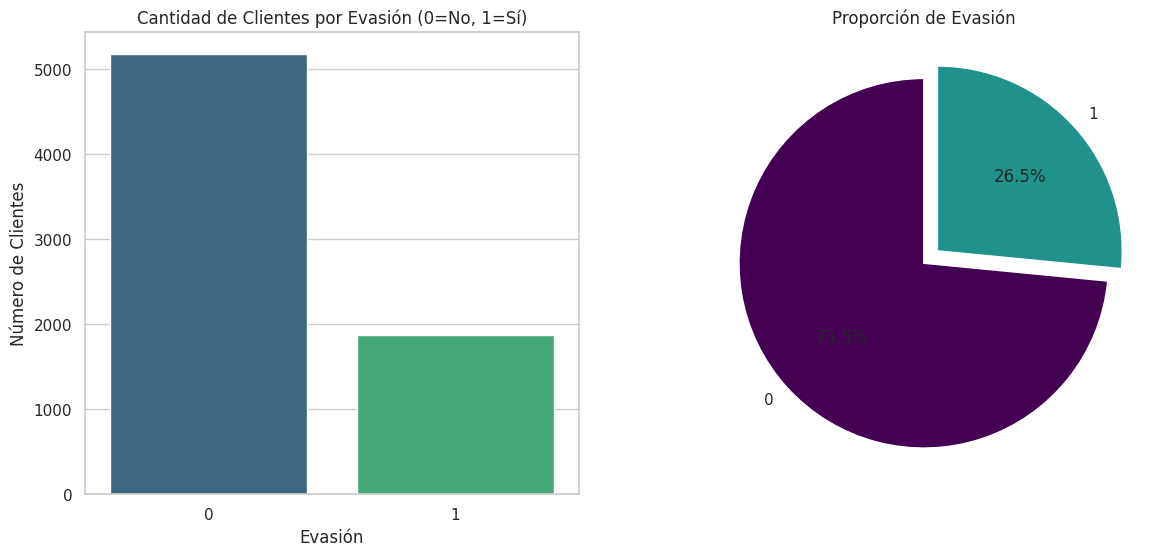

In [60]:
# Importar librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# Crear una figura con dos subgráficos (uno al lado del otro)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico de Barras (Frecuencia Absoluta)
sns.countplot(data=df_churn, x='Churn', ax=ax[0], palette='viridis')
ax[0].set_title('Cantidad de Clientes por Evasión (0=No, 1=Sí)')
ax[0].set_xlabel('Evasión')
ax[0].set_ylabel('Número de Clientes')

# 2. Gráfico de Torta (Proporción Porcentual)
# Calculamos la distribución de la columna Churn
df_churn['Churn'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    ax=ax[1],
    colors=['#440154', '#21918c'], # Colores de la paleta viridis
    explode=(0, 0.1) # Resalta la tajada de los que se fueron
)
ax[1].set_title('Proporción de Evasión')
ax[1].set_ylabel('') # Quitar etiqueta lateral para que se vea más limpio

# Mostrar los gráficos en el Notebook
plt.show()

### Insights de la Distribución de evasión

1. **El diagnóstico: "Fuga Crítica"**

La proporción de 26.5% de evasión es el hallazgo principal. El gráfico de torta resalta que más de 1 de cada 4 clientes decide dejar la empresa. Esto representa una pérdida constante de ingresos y un alto costo de adquisición de nuevos clientes para compensar a los que se van.

2. **Desequilibrio de Datos**

El gráfico de barras (a la izquierda) muestra que tienes aproximadamente 5.174 clientes que permanecen ($0$) frente a unos 1.869 que se han ido ($1$).
  
3. **Insights para el Negocio**

  - Estabilidad: El 73.5% de retención es la base sólida de la empresa, pero no es suficiente para un crecimiento sostenible si la fuga no se controla.

## Recuento de evasión por variables categóricas

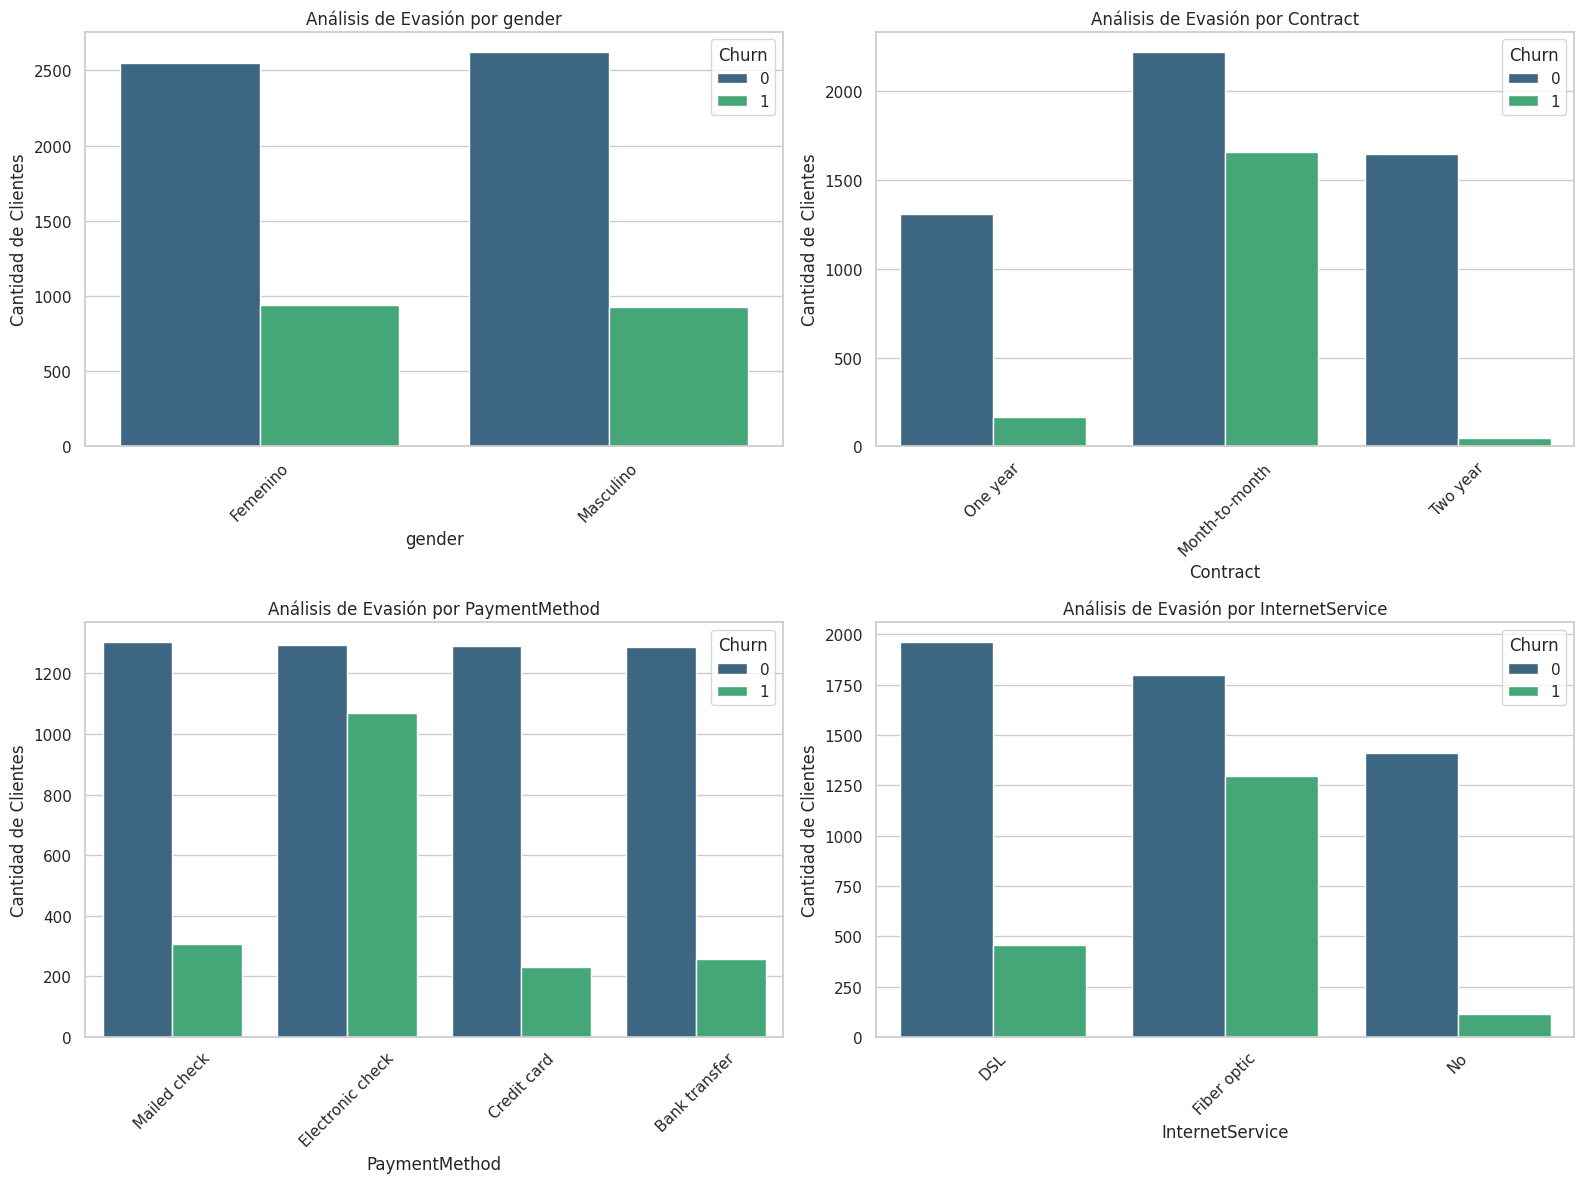

In [61]:
# 1. Definir las variables que queremos investigar
variables_a_graficar = ['gender', 'Contract', 'PaymentMethod', 'InternetService']

# 2. Configurar el lienzo (la figura) para mostrar 4 gráficos (2 filas y 2 columnas)
plt.figure(figsize=(16, 12))

# 3. Usar un bucle 'for' para crear los gráficos de forma eficiente
for i, columna in enumerate(variables_a_graficar, 1):
    plt.subplot(2, 2, i) # Define la posición del gráfico en la cuadrícula

    # Crear el gráfico de barras comparativo
    # 'hue' es el parámetro mágico: divide las barras según si hubo evasión o no
    sns.countplot(data=df_churn, x=columna, hue='Churn', palette='viridis')

    # Personalizar cada gráfico
    plt.title(f'Análisis de Evasión por {columna}')
    plt.xlabel(columna)
    plt.ylabel('Cantidad de Clientes')

    # Rotar las etiquetas del eje X para que no se amontonen (especialmente en PaymentMethod)
    plt.xticks(rotation=45)

# 4. Ajustar el espacio entre gráficos para que sea legible
plt.tight_layout()
plt.show()

### Insights de Recuento de evasión por variables categóricas

1. **Evasión por Género (gender)**

Las barras son prácticamente idénticas entre "Femenino" y "Masculino".

2. **Evasión por Tipo de Contrato (Contract)**

Este es el gráfico más impactante. Los clientes con contrato Month-to-month (Mes a mes) tienen una tasa de evasión altísima. En cambio, los contratos de uno y dos años casi no tienen fugas.

3. **Evasión por Método de Pago (PaymentMethod)**

El método Electronic check (Cheque electrónico) muestra una desproporción enorme de fuga comparado con los demás (Mailed check, Credit card, Bank transfer).

4. **Evasión por Servicio de Internet (InternetService)**

Los clientes de Fiber optic (Fibra óptica) se están yendo mucho más que los de DSL o los que no tienen internet.

## Conteo de evasión por variables numéricas

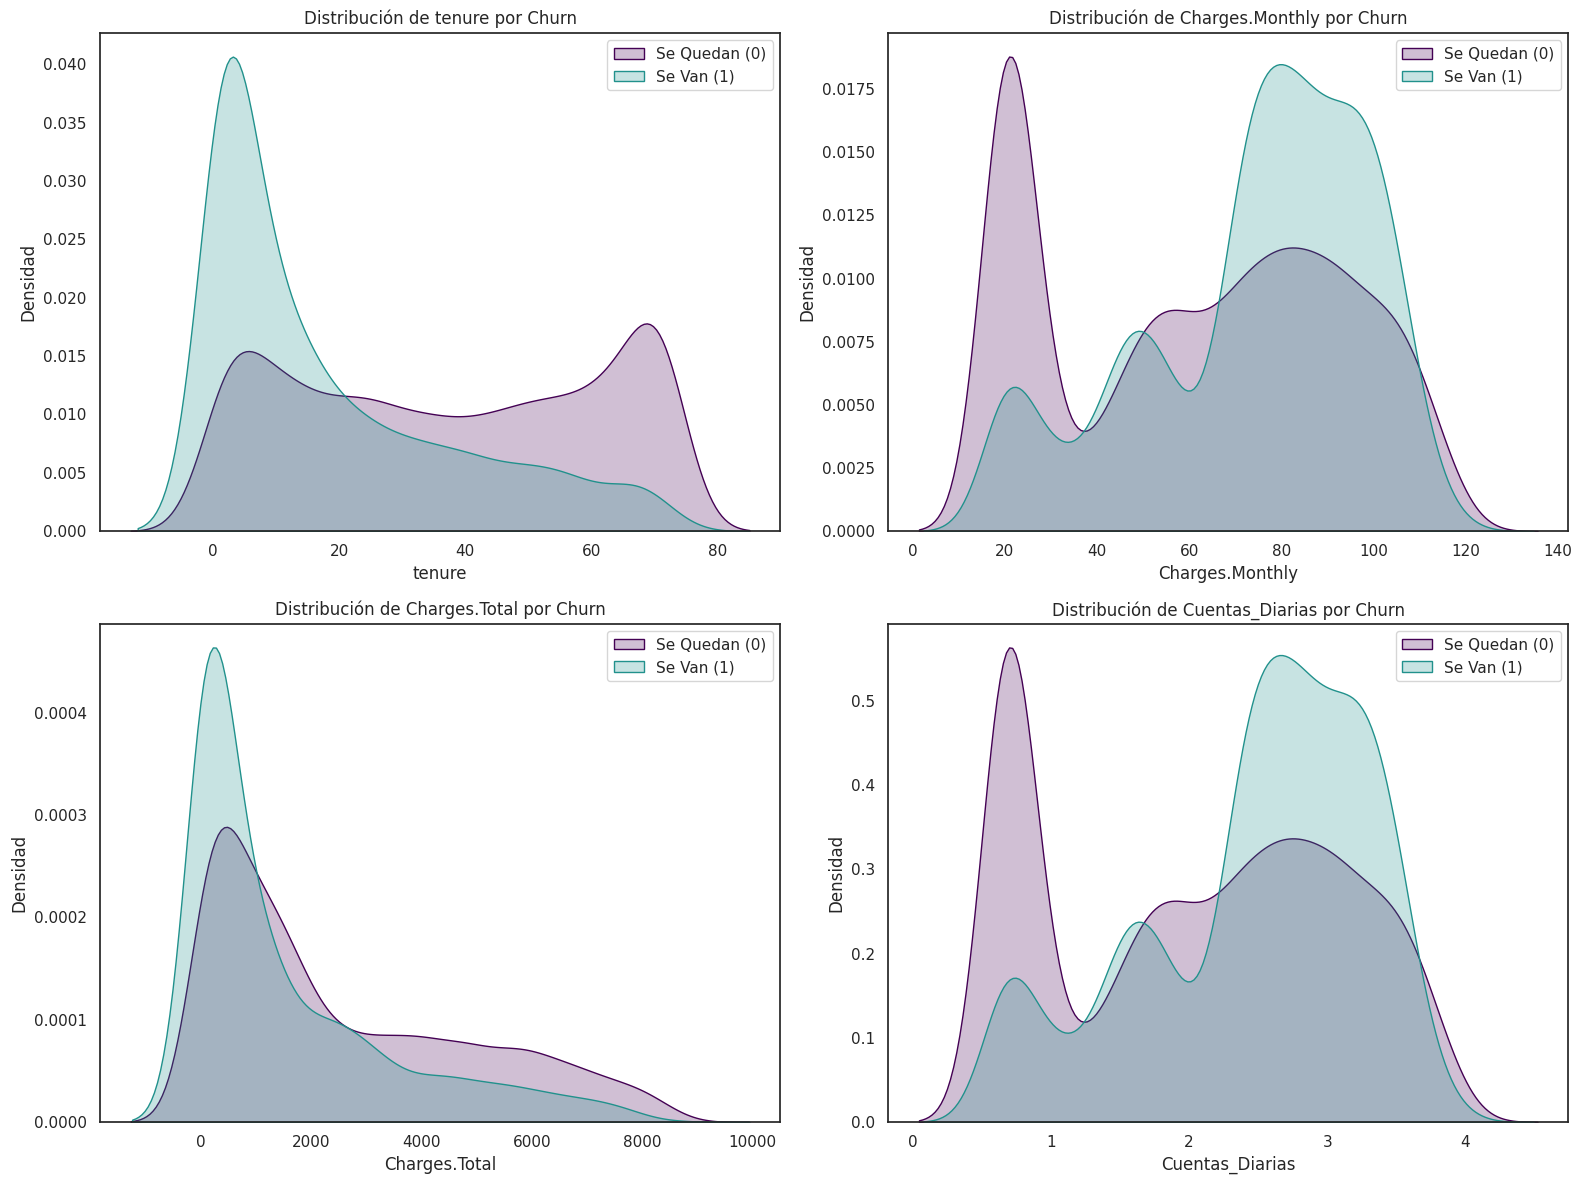

In [62]:
# Importar librerías si no se han importado antes
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo
sns.set_theme(style="white")

# Lista de variables numéricas a analizar
vars_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']

# Crear una cuadrícula de 2x2 para los gráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() # Aplanar la matriz para iterar fácilmente

for i, col in enumerate(vars_numericas):
    # Graficar la distribución de los que se quedan (Churn=0)
    sns.kdeplot(df_churn[df_churn['Churn'] == 0][col],
                shade=True, label='Se Quedan (0)', ax=axes[i], color='#440154')

    # Graficar la distribución de los que se van (Churn=1)
    sns.kdeplot(df_churn[df_churn['Churn'] == 1][col],
                shade=True, label='Se Van (1)', ax=axes[i], color='#21918c')

    # Configuración de títulos y etiquetas
    axes[i].set_title(f'Distribución de {col} por Churn')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densidad')
    axes[i].legend()

# Ajustar el espacio entre los gráficos
plt.tight_layout()
plt.show()

### Insights Conteo de evasión por variables numéricas

1. **El Factor Tiempo (tenure)**

  - La curva verde (Se Van) tiene un pico masivo cerca del mes 0 al 10. Por el contrario, la curva morada (Se Quedan) crece hacia los 70 meses.

  - Existe una crisis de retención temprana. Si el cliente sobrevive al primer año, la probabilidad de fuga cae drásticamente. Los clientes antiguos son extremadamente leales.

2. **El Factor Costo (Charges.Monthly y Cuentas_Diarias)**

  - Según se observa en el pico de la curva morada que está en los 20 dólares (planes económicos): casi nadie se va ahí. Sin embargo, en el rango de 70 a 100 dólares (y más de 2.5 en cuentas diarias), la curva verde supera por mucho a la morada.

  - Los clientes con planes Premium o caros son los que más desertan. Esto sugiere que no están percibiendo un valor proporcional a lo que pagan o que la competencia tiene mejores ofertas para el segmento de alto gasto.

  - Esto coincide con lo que vimos de la Fibra Óptica; al ser un servicio más caro, es coherente que la fuga se concentre en montos altos.

3. **Gasto Acumulado (Charges.Total)**

  - La gran mayoría de la evasión ocurre en montos totales bajos.

  - Esto confirma que la empresa está perdiendo clientes antes de que lleguen a ser rentables. No alcanzan a "pagar" su costo de adquisición porque se van muy pronto.

#📄**Informe final**

## 📊 **Análisis de Evasión de Clientes (Churn) - Telecom X**

### 1. **Introducción**

El objetivo de este proyecto fue analizar el comportamiento de los clientes de Telecom X para identificar los factores críticos que influyen en la pérdida de suscriptores. El Churn (evasión) es un problema financiero grave, ya que el costo de adquirir un nuevo cliente es significativamente mayor que el de retener a uno actual. A través de este análisis, buscamos proporcionar al equipo de Data Science una base sólida para el desarrollo de modelos predictivos y estrategias de retención.

### 2. **Limpieza y Tratamiento de Datos**

Para asegurar la calidad del análisis, se llevaron a cabo los siguientes procesos de ETL:

- **Extracción**: Se importaron los datos desde una API JSON, utilizando técnicas de normalización para aplanar estructuras anidadas.

- **Tratamiento de Tipos**: Se convirtieron variables críticas como Charges.Total de texto a formato numérico.

- **Gestión de Nulos**: Se identificaron y trataron valores faltantes (rellenando con 0 en cargos totales para clientes nuevos con antigüedad 0).

- **Estandarización**: Se tradujeron categorías al español y se transformaron variables binarias (Sí/No) a formato numérico (1/0) para facilitar el cálculo estadístico.

- **Ingeniería de Variables**: Se creó la métrica Cuentas_Diarias para entender el impacto económico cotidiano en el cliente.

### 3. **Análisis Exploratorio de Datos (EDA)**

Tras analizar las 7.043 entradas limpias, las visualizaciones estratégicas revelaron patrones claros:

- **Distribución General**: La tasa de evasión actual es del 26.5%.

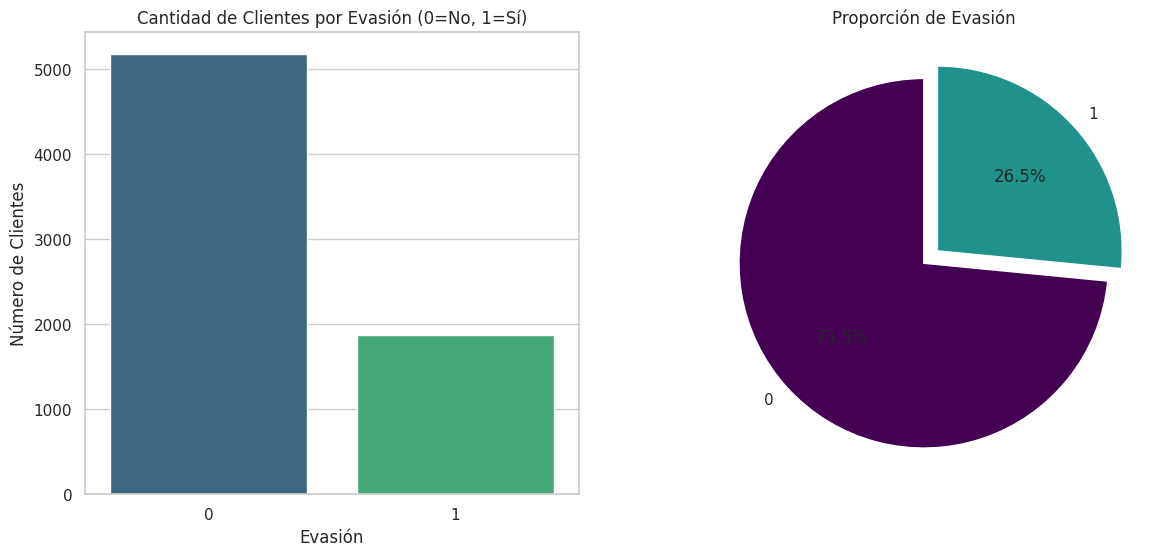

-- --

- **Factores Categóricos**: El tipo de contrato mes a mes y el uso de fibra óptica presentan las tasas más altas de fuga. El método de pago por cheque electrónico también está fuertemente correlacionado con la evasión.

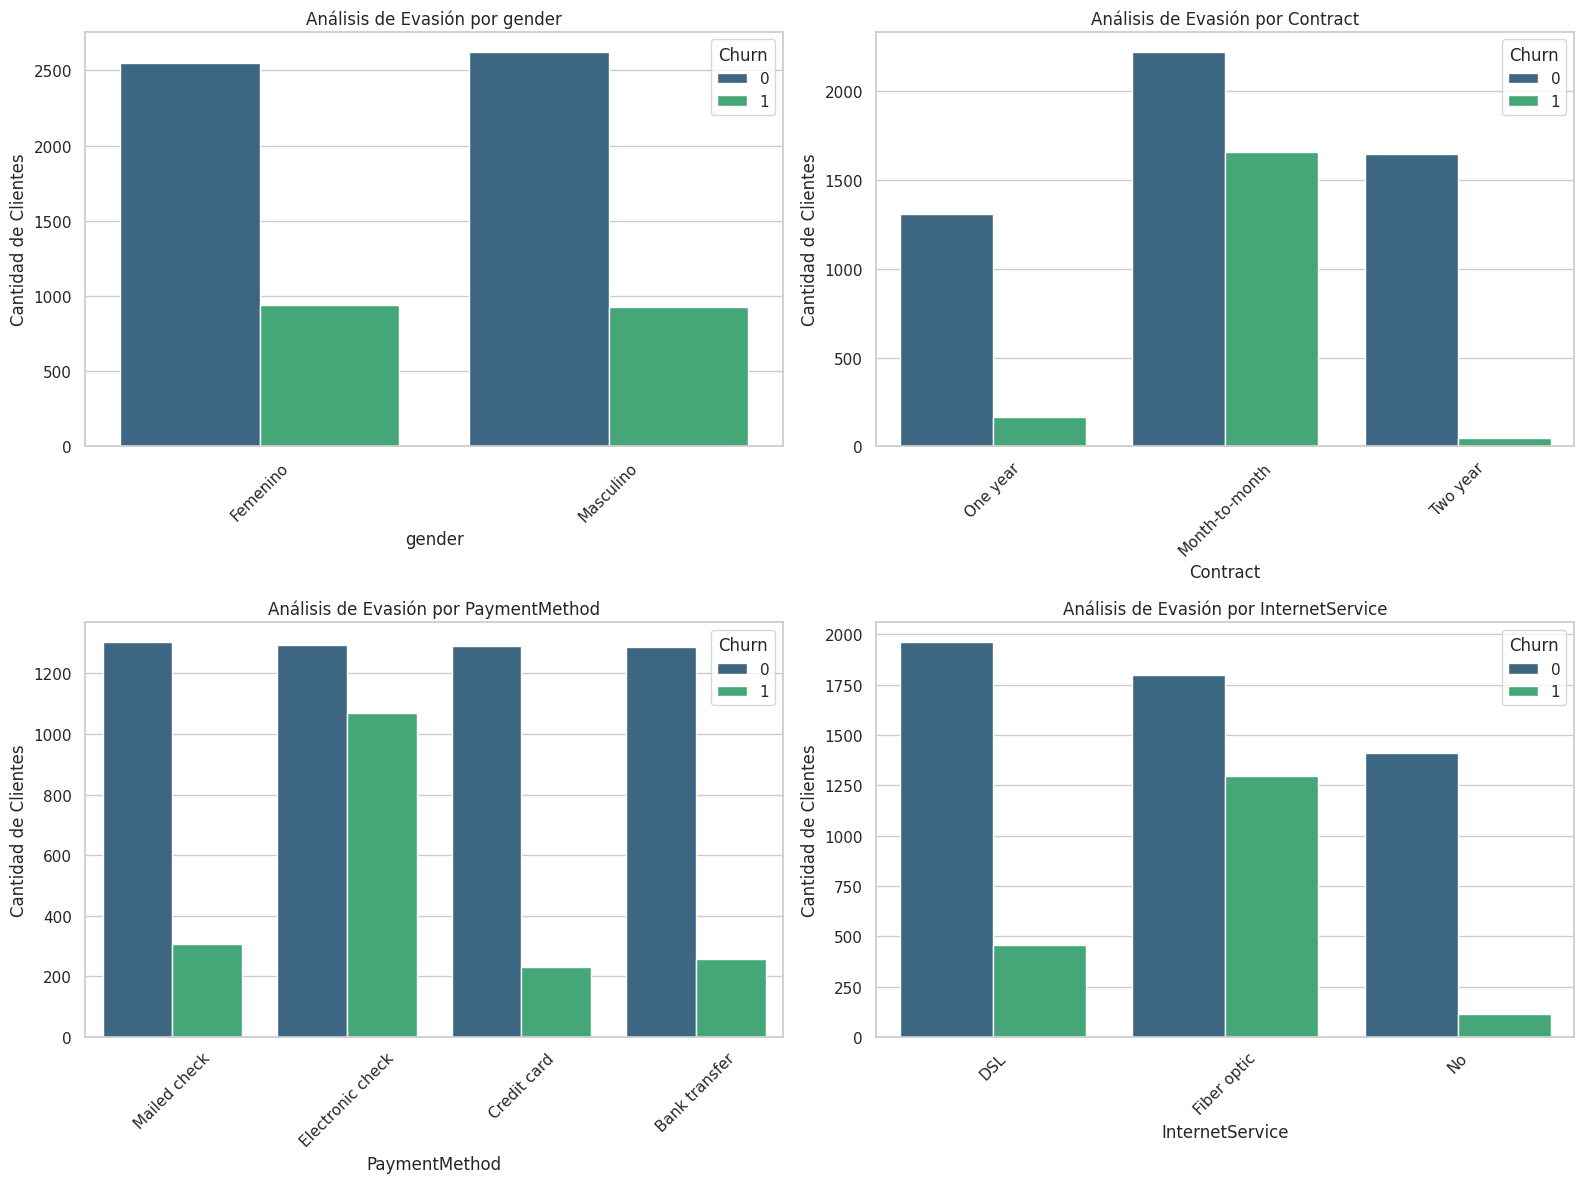

-- --

- **Factores Numéricos**: Los gráficos de densidad muestran que la evasión se concentra en los primeros 12 meses de servicio y en clientes con facturas mensuales altas (entre $70 y $100).

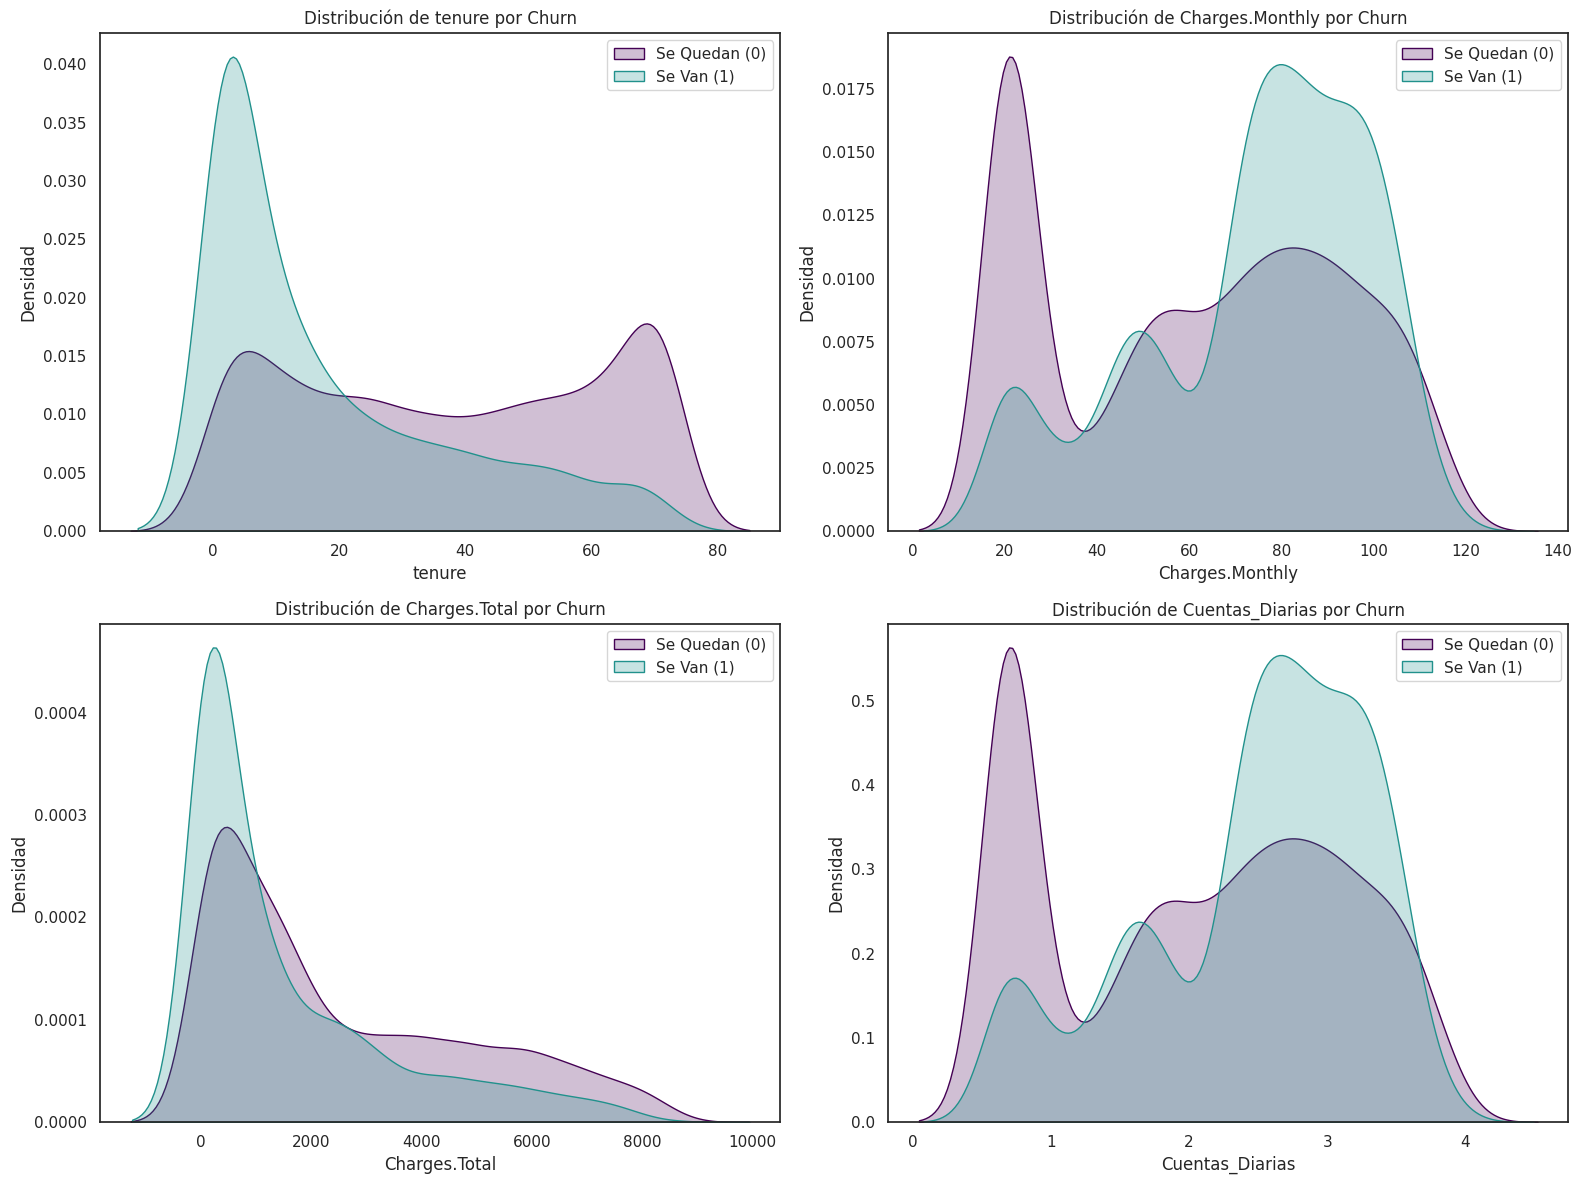

### 4. **Conclusiones e Insights**

Los datos sugieren que la evasión en Telecom X no es aleatoria, sino que sigue un perfil de riesgo específico:

1. **Vulnerabilidad Temprana**: Los clientes nuevos tienen una probabilidad de fuga drásticamente mayor.

2. **Sensibilidad al Precio**: El segmento "Premium" (usuarios de fibra y cargos altos) es el más volátil.

3. **Falta de Fidelización**: Los contratos a corto plazo no generan barreras de salida suficientes para retener al cliente ante ofertas de la competencia.

5. **Recomendaciones Estratégicas**

Basado en la evidencia, se sugieren las siguientes acciones:

- **Plan de Bienvenida**: Implementar un programa de acompañamiento y descuentos durante los primeros 6 meses para superar la "zona de riesgo" de antigüedad.

- **Incentivo de Contrato**: Ofrecer beneficios exclusivos (como meses gratis o mejoras de velocidad) a quienes migren de un contrato mensual a uno anual.

- **Fomento de Pago Automático**: Promover la suscripción a pagos por tarjeta de crédito o transferencia bancaria para reducir la fricción del cheque electrónico.

- **Revisión de Valor en Fibra Óptica**: Realizar una auditoría de calidad técnica o de precios en el servicio de fibra para asegurar que el valor percibido justifique el costo.